## Fire Detection Pipeline (ResNet18)

## 1. Setup & Konfiguration


In [8]:
# Imports
import os
import time
import shutil
from pathlib import Path
from collections import OrderedDict, Counter
from functools import partial
from random import randint, sample
import numpy as np

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, random_split
from torchvision import datasets, transforms

from PIL import Image
import matplotlib.pyplot as plt

In [9]:
# Pfade
DFIRE_DIR = "./D-Fire"                       # Originales D-Fire Dataset (YOLO-Format)
OUTPUT_DIR = "./classification_dataset/train"      # Output Preprocessing
MODEL_SAVE_PATH = "./best_model.pth"         # Checkpoint des besten Modells
PLOT_SAVE_PATH = "./training_plot.png"       # Trainings-Plot

# Preprocessing 
CLASS_MAP = {0: "fire", 1: "smoke"}
MIN_CROP_SIZE = 32

# Daten / Transforms 
IMAGE_SIZE = 224
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD = [0.229, 0.224, 0.225]

# Training-Hyperparameter 
EPOCHS = 25
BATCH_SIZE = 32
LR = 1e-3
WEIGHT_DECAY = 1e-4
VAL_SPLIT = 0.2
NUM_WORKERS = 0  

In [10]:
# Device automatisch wählen (MPS / CUDA / CPU)
def get_device():
    if torch.backends.mps.is_available():
        device = torch.device("mps")
        print("Using Apple MPS (Metal Performance Shaders)")
    elif torch.cuda.is_available():
        device = torch.device("cuda")
        print(f"Using CUDA ({torch.cuda.get_device_name(0)})")
    else:
        device = torch.device("cpu")
        print("Using CPU")
    return device

device = get_device()

Using Apple MPS (Metal Performance Shaders)


## 3. Dataset & DataLoader

Transforms (Resize, Augmentation, Normalisierung) und Train/Val-Split.

In [11]:
train_transforms = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.RandomHorizontalFlip(),  # 50% Wahrscheinlichkeit
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
])

val_transforms = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
])


def get_dataloaders(data_dir: str, batch_size: int = 32,
                    val_split: float = 0.2, num_workers: int = 0):
    print(data_dir)
    full_dataset = datasets.ImageFolder(data_dir, transform=train_transforms)
    class_names = full_dataset.classes
    n_classes = len(class_names)
    n_val = int(len(full_dataset) * val_split)
    n_train = len(full_dataset) - n_val
    generator = torch.Generator().manual_seed(42)
    train_set, val_set = random_split(full_dataset, [n_train, n_val], generator=generator)
    # After the random_split, make a clean copy for counterfactual use
    cf_set = datasets.ImageFolder(data_dir, transform=val_transforms)  # no augmentation
    cf_train_set, _ = random_split(cf_set, [n_train, n_val], generator=generator)  # same split

    val_set.dataset = datasets.ImageFolder(data_dir, transform=val_transforms)

    train_loader = DataLoader(train_set, batch_size=batch_size, shuffle=True,
                            num_workers=num_workers, pin_memory=True)
    val_loader = DataLoader(val_set, batch_size=batch_size, shuffle=False,
                            num_workers=num_workers, pin_memory=True)

    print(f"Dataset : {data_dir}")
    print(f"Classes : {n_classes}  {class_names}")
    print(f"Train   : {n_train}   Val: {n_val}")

    return train_loader, val_loader, cf_train_set, class_names, n_classes  # ← added cf_train_set

## 4. Modell — ResNet18

Eigene ResNet-Implementierung mit Encoder (Residual Blocks) + Decoder (Global Avg Pool + FC).

In [12]:
class Conv2dAuto(nn.Conv2d):
    """Conv2d mit automatischem 'same' Padding basierend auf der Kernel-Größe."""
    def __init__(self, *args, **kwargs):
        super().__init__(*args, **kwargs)
        self.padding = (self.kernel_size[0] // 2, self.kernel_size[1] // 2)


conv3x3 = partial(Conv2dAuto, kernel_size=3, bias=False)


class ResidualBlock(nn.Module):
    """Basis Residual Block: output = blocks(x) + shortcut(x)."""
    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.in_channels = in_channels
        self.out_channels = out_channels
        self.blocks = nn.Identity()
        self.shortcut = nn.Identity()

    def forward(self, x):
        residual = self.shortcut(x) if self.should_apply_shortcut else x
        x = self.blocks(x)
        x += residual
        return x

    @property
    def should_apply_shortcut(self):
        return self.in_channels != self.out_channels


class ResNetResidualBlock(ResidualBlock):
    """ResNet Residual Block mit Expansion und optionalem Downsampling."""
    def __init__(self, in_channels, out_channels, expansion=1,
                 downsampling=1, conv=conv3x3, *args, **kwargs):
        super().__init__(in_channels, out_channels)
        self.expansion = expansion
        self.downsampling = downsampling
        self.conv = conv
        self.shortcut = (
            nn.Sequential(OrderedDict({
                'conv': nn.Conv2d(self.in_channels, self.expanded_channels,
                                  kernel_size=1, stride=self.downsampling, bias=False),
                'bn': nn.BatchNorm2d(self.expanded_channels)
            }))
            if self.should_apply_shortcut else None
        )

    @property
    def expanded_channels(self):
        return self.out_channels * self.expansion

    @property
    def should_apply_shortcut(self):
        return self.in_channels != self.expanded_channels


def conv_bn(in_channels, out_channels, conv, *args, **kwargs):
    """Convolution gefolgt von BatchNorm."""
    return nn.Sequential(OrderedDict({
        'conv': conv(in_channels, out_channels, *args, **kwargs),
        'bn': nn.BatchNorm2d(out_channels)
    }))


class ResNetBasicBlock(ResNetResidualBlock):
    """Basic Block: zwei 3x3 conv/bn Layer mit ReLU."""
    expansion = 1

    def __init__(self, in_channels, out_channels, activation=nn.ReLU, *args, **kwargs):
        super().__init__(in_channels, out_channels, *args, **kwargs)
        self.blocks = nn.Sequential(
            conv_bn(self.in_channels, self.out_channels, conv=self.conv,
                    bias=False, stride=self.downsampling),
            activation(),
            conv_bn(self.out_channels, self.expanded_channels, conv=self.conv, bias=False),
        )


class ResNetBottleNeckBlock(ResNetResidualBlock):
    """Bottleneck Block: 1x1 -> 3x3 -> 1x1 conv/bn Layer."""
    expansion = 4

    def __init__(self, in_channels, out_channels, activation=nn.ReLU, *args, **kwargs):
        super().__init__(in_channels, out_channels, expansion=4, *args, **kwargs)
        self.blocks = nn.Sequential(
            conv_bn(self.in_channels, self.out_channels, self.conv, kernel_size=1),
            activation(),
            conv_bn(self.out_channels, self.out_channels, self.conv,
                    kernel_size=3, stride=self.downsampling),
            activation(),
            conv_bn(self.out_channels, self.expanded_channels, self.conv, kernel_size=1),
        )

In [13]:
class ResNetLayer(nn.Module):
    """Ein Layer, bestehend aus n gestapelten Residual Blocks."""
    def __init__(self, in_channels, out_channels, block=ResNetBasicBlock, n=1, *args, **kwargs):
        super().__init__()
        downsampling = 2 if in_channels != out_channels else 1
        self.blocks = nn.Sequential(
            block(in_channels, out_channels, *args, **kwargs, downsampling=downsampling),
            *[block(out_channels * block.expansion, out_channels,
                    downsampling=1, *args, **kwargs) for _ in range(n - 1)]
        )

    def forward(self, x):
        return self.blocks(x)


class ResNetEncoder(nn.Module):
    """ResNet Encoder: Gate (7x7 conv + pool) gefolgt von Residual Layers."""
    def __init__(self, in_channels=3, blocks_sizes=(64, 128, 256, 512),
                 depths=(2, 2, 2, 2), activation=nn.ReLU,
                 block=ResNetBasicBlock, *args, **kwargs):
        super().__init__()
        self.blocks_sizes = blocks_sizes

        self.gate = nn.Sequential(
            nn.Conv2d(in_channels, blocks_sizes[0], kernel_size=7,
                      stride=2, padding=3, bias=False),
            nn.BatchNorm2d(blocks_sizes[0]),
            activation(),
            nn.MaxPool2d(kernel_size=3, stride=2, padding=1)
        )

        self.in_out_block_sizes = list(zip(blocks_sizes, blocks_sizes[1:]))
        self.blocks = nn.ModuleList([
            ResNetLayer(blocks_sizes[0], blocks_sizes[0], n=depths[0],
                        activation=activation, block=block, *args, **kwargs),
            *[ResNetLayer(in_ch * block.expansion, out_ch, n=n,
                          activation=activation, block=block, *args, **kwargs)
              for (in_ch, out_ch), n in zip(self.in_out_block_sizes, depths[1:])]
        ])

    def forward(self, x):
        x = self.gate(x)
        for block in self.blocks:
            x = block(x)
        return x


class ResNetDecoder(nn.Module):
    """Global Average Pool gefolgt von Fully Connected Classifier."""
    def __init__(self, in_features, n_classes):
        super().__init__()
        self.avg = nn.AdaptiveAvgPool2d((1, 1))
        self.decoder = nn.Linear(in_features, n_classes)

    def forward(self, x):
        x = self.avg(x)
        x = x.view(x.size(0), -1)
        x = self.decoder(x)
        return x


class ResNet(nn.Module):
    """Komplettes ResNet: Encoder + Decoder."""
    def __init__(self, in_channels, n_classes, *args, **kwargs):
        super().__init__()
        self.encoder = ResNetEncoder(in_channels, *args, **kwargs)
        self.decoder = ResNetDecoder(
            self.encoder.blocks[-1].blocks[-1].expanded_channels, n_classes
        )

    def forward(self, x):
        x = self.encoder(x)
        x = self.decoder(x)
        return x


# Factory Functions
def resnet18(in_channels, n_classes):
    return ResNet(in_channels, n_classes, block=ResNetBasicBlock, depths=[2, 2, 2, 2])

def resnet34(in_channels, n_classes):
    return ResNet(in_channels, n_classes, block=ResNetBasicBlock, depths=[3, 4, 6, 3])

def resnet50(in_channels, n_classes):
    return ResNet(in_channels, n_classes, block=ResNetBottleNeckBlock, depths=[3, 4, 6, 3])

def resnet101(in_channels, n_classes):
    return ResNet(in_channels, n_classes, block=ResNetBottleNeckBlock, depths=[3, 4, 23, 3])

def resnet152(in_channels, n_classes):
    return ResNet(in_channels, n_classes, block=ResNetBottleNeckBlock, depths=[3, 8, 36, 3])

# 7. **Modell Laden für Counterfactuals**

./best_model.pth
./classification_dataset/train
Dataset : ./classification_dataset/train
Classes : 2  ['fire', 'no_fire']
Train   : 14417   Val: 3604
Query Label: 1 (no_fire) | Konfidenz: 0.9968
CF Target: 0 (fire)
MAD
14417
NO MAD
Seed 0
λ-Schleife 
0
  Schritt 0: probs[fire]=0.0032, probs[no_fire]=0.9968, delta_mean=0.000999, cls=5.7358, dist=0.000000
Seed 0 | λ=0.0100 | Schritt 000 | Loss: 0.0574 | Pred: no_fire


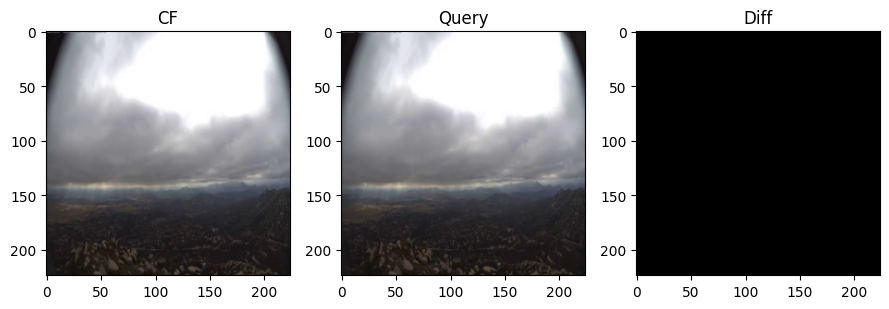

  Schritt 1: probs[fire]=0.0107, probs[no_fire]=0.9893, delta_mean=0.001799, cls=4.5331, dist=0.001329
  Schritt 2: probs[fire]=0.0332, probs[no_fire]=0.9668, delta_mean=0.002565, cls=3.4058, dist=0.002400
  Schritt 3: probs[fire]=0.0928, probs[no_fire]=0.9072, delta_mean=0.003330, cls=2.3776, dist=0.003423
  Schritt 4: probs[fire]=0.2257, probs[no_fire]=0.7743, delta_mean=0.004062, cls=1.4886, dist=0.004438
  Schritt 5: probs[fire]=0.4365, probs[no_fire]=0.5635, delta_mean=0.004746, cls=0.8291, dist=0.005409
  Schritt 6: probs[fire]=0.6503, probs[no_fire]=0.3497, delta_mean=0.005358, cls=0.4304, dist=0.006311
  Schritt 7: probs[fire]=0.8037, probs[no_fire]=0.1963, delta_mean=0.005886, cls=0.2185, dist=0.007118
✓ Zielklasse erreicht | Seed 0 | λ=0.0100 | Schritt 7
λ-Schleife 
1
  Schritt 0: probs[fire]=0.0032, probs[no_fire]=0.9968, delta_mean=0.000999, cls=5.7358, dist=0.000000
Seed 0 | λ=0.0150 | Schritt 000 | Loss: 0.0860 | Pred: no_fire


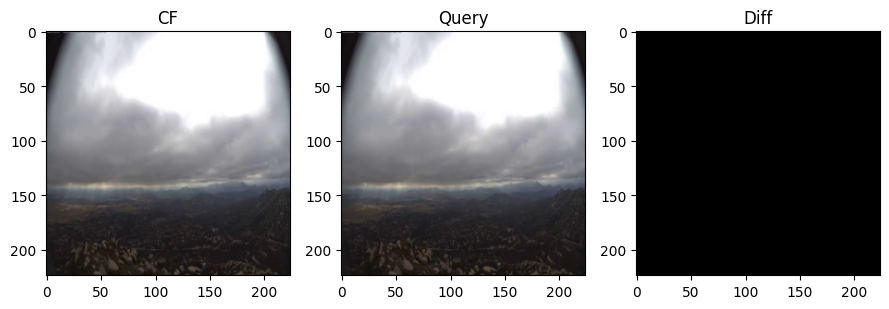

  Schritt 1: probs[fire]=0.0107, probs[no_fire]=0.9893, delta_mean=0.001836, cls=4.5330, dist=0.001330
  Schritt 2: probs[fire]=0.0333, probs[no_fire]=0.9667, delta_mean=0.002638, cls=3.4015, dist=0.002450
  Schritt 3: probs[fire]=0.0936, probs[no_fire]=0.9064, delta_mean=0.003435, cls=2.3691, dist=0.003521
  Schritt 4: probs[fire]=0.2283, probs[no_fire]=0.7717, delta_mean=0.004205, cls=1.4773, dist=0.004582
  Schritt 5: probs[fire]=0.4415, probs[no_fire]=0.5585, delta_mean=0.004930, cls=0.8176, dist=0.005602
  Schritt 6: probs[fire]=0.6566, probs[no_fire]=0.3434, delta_mean=0.005590, cls=0.4207, dist=0.006561
  Schritt 7: probs[fire]=0.8098, probs[no_fire]=0.1902, delta_mean=0.006172, cls=0.2110, dist=0.007431
✓ Zielklasse erreicht | Seed 0 | λ=0.0150 | Schritt 7
λ-Schleife 
2
  Schritt 0: probs[fire]=0.0032, probs[no_fire]=0.9968, delta_mean=0.000999, cls=5.7358, dist=0.000000
Seed 0 | λ=0.0225 | Schritt 000 | Loss: 0.1291 | Pred: no_fire


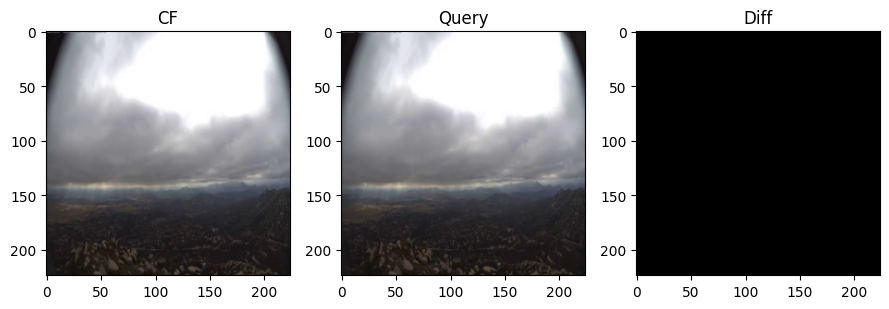

  Schritt 1: probs[fire]=0.0107, probs[no_fire]=0.9893, delta_mean=0.001859, cls=4.5330, dist=0.001330
  Schritt 2: probs[fire]=0.0334, probs[no_fire]=0.9666, delta_mean=0.002685, cls=3.3996, dist=0.002482
  Schritt 3: probs[fire]=0.0939, probs[no_fire]=0.9061, delta_mean=0.003504, cls=2.3654, dist=0.003586
  Schritt 4: probs[fire]=0.2294, probs[no_fire]=0.7706, delta_mean=0.004297, cls=1.4724, dist=0.004676
  Schritt 5: probs[fire]=0.4435, probs[no_fire]=0.5565, delta_mean=0.005048, cls=0.8130, dist=0.005728
  Schritt 6: probs[fire]=0.6592, probs[no_fire]=0.3408, delta_mean=0.005740, cls=0.4167, dist=0.006722
  Schritt 7: probs[fire]=0.8124, probs[no_fire]=0.1876, delta_mean=0.006361, cls=0.2077, dist=0.007635
✓ Zielklasse erreicht | Seed 0 | λ=0.0225 | Schritt 7
λ-Schleife 
3
  Schritt 0: probs[fire]=0.0032, probs[no_fire]=0.9968, delta_mean=0.001000, cls=5.7358, dist=0.000000
Seed 0 | λ=0.0338 | Schritt 000 | Loss: 0.1936 | Pred: no_fire


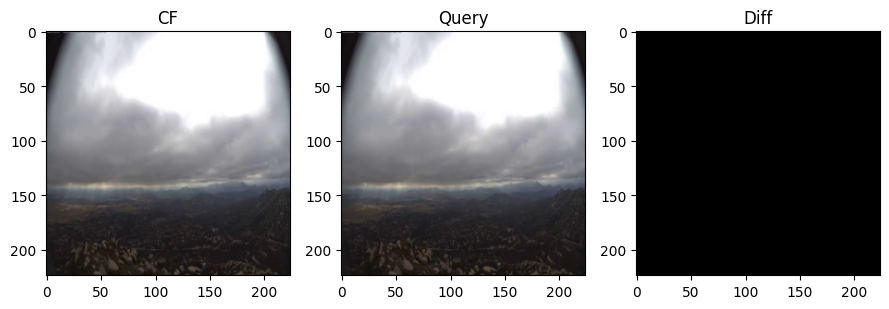

  Schritt 1: probs[fire]=0.0107, probs[no_fire]=0.9893, delta_mean=0.001874, cls=4.5330, dist=0.001330
  Schritt 2: probs[fire]=0.0334, probs[no_fire]=0.9666, delta_mean=0.002716, cls=3.3987, dist=0.002503
  Schritt 3: probs[fire]=0.0941, probs[no_fire]=0.9059, delta_mean=0.003549, cls=2.3639, dist=0.003628
  Schritt 4: probs[fire]=0.2298, probs[no_fire]=0.7702, delta_mean=0.004356, cls=1.4704, dist=0.004737
  Schritt 5: probs[fire]=0.4444, probs[no_fire]=0.5556, delta_mean=0.005125, cls=0.8110, dist=0.005809
  Schritt 6: probs[fire]=0.6604, probs[no_fire]=0.3396, delta_mean=0.005839, cls=0.4148, dist=0.006827
  Schritt 7: probs[fire]=0.8137, probs[no_fire]=0.1863, delta_mean=0.006485, cls=0.2061, dist=0.007770
✓ Zielklasse erreicht | Seed 0 | λ=0.0338 | Schritt 7
λ-Schleife 
4
  Schritt 0: probs[fire]=0.0032, probs[no_fire]=0.9968, delta_mean=0.001000, cls=5.7358, dist=0.000000
Seed 0 | λ=0.0506 | Schritt 000 | Loss: 0.2904 | Pred: no_fire


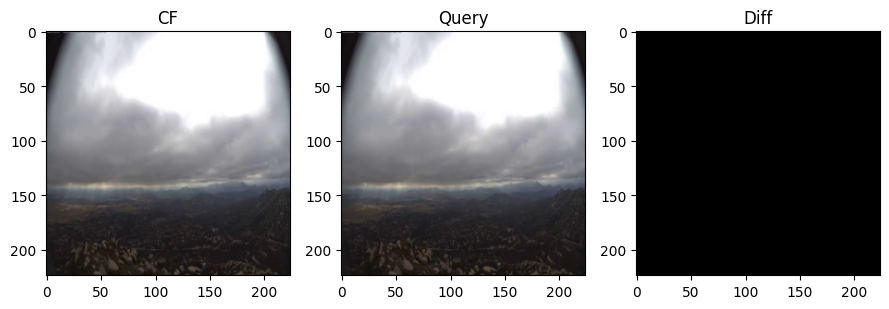

  Schritt 1: probs[fire]=0.0107, probs[no_fire]=0.9893, delta_mean=0.001884, cls=4.5329, dist=0.001330
  Schritt 2: probs[fire]=0.0334, probs[no_fire]=0.9666, delta_mean=0.002735, cls=3.3984, dist=0.002516
  Schritt 3: probs[fire]=0.0941, probs[no_fire]=0.9059, delta_mean=0.003576, cls=2.3633, dist=0.003653
  Schritt 4: probs[fire]=0.2300, probs[no_fire]=0.7700, delta_mean=0.004394, cls=1.4695, dist=0.004775
  Schritt 5: probs[fire]=0.4449, probs[no_fire]=0.5551, delta_mean=0.005174, cls=0.8100, dist=0.005861
  Schritt 6: probs[fire]=0.6611, probs[no_fire]=0.3389, delta_mean=0.005901, cls=0.4139, dist=0.006894
  Schritt 7: probs[fire]=0.8144, probs[no_fire]=0.1856, delta_mean=0.006566, cls=0.2053, dist=0.007856
✓ Zielklasse erreicht | Seed 0 | λ=0.0506 | Schritt 7
λ-Schleife 
5
  Schritt 0: probs[fire]=0.0032, probs[no_fire]=0.9968, delta_mean=0.001000, cls=5.7358, dist=0.000000
Seed 0 | λ=0.0759 | Schritt 000 | Loss: 0.4356 | Pred: no_fire


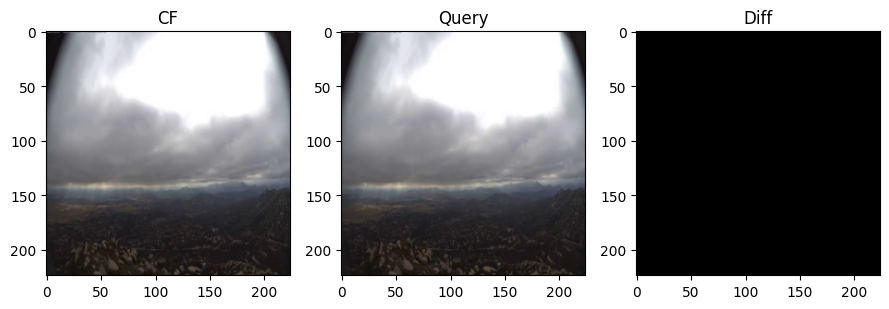

  Schritt 1: probs[fire]=0.0107, probs[no_fire]=0.9893, delta_mean=0.001890, cls=4.5329, dist=0.001330
  Schritt 2: probs[fire]=0.0334, probs[no_fire]=0.9666, delta_mean=0.002747, cls=3.3983, dist=0.002524
  Schritt 3: probs[fire]=0.0941, probs[no_fire]=0.9059, delta_mean=0.003594, cls=2.3631, dist=0.003670
  Schritt 4: probs[fire]=0.2301, probs[no_fire]=0.7699, delta_mean=0.004417, cls=1.4692, dist=0.004799
  Schritt 5: probs[fire]=0.4450, probs[no_fire]=0.5550, delta_mean=0.005204, cls=0.8097, dist=0.005893
  Schritt 6: probs[fire]=0.6613, probs[no_fire]=0.3387, delta_mean=0.005941, cls=0.4136, dist=0.006936
  Schritt 7: probs[fire]=0.8146, probs[no_fire]=0.1854, delta_mean=0.006617, cls=0.2050, dist=0.007912
✓ Zielklasse erreicht | Seed 0 | λ=0.0759 | Schritt 7
λ-Schleife 
6
  Schritt 0: probs[fire]=0.0032, probs[no_fire]=0.9968, delta_mean=0.001000, cls=5.7358, dist=0.000000
Seed 0 | λ=0.1139 | Schritt 000 | Loss: 0.6533 | Pred: no_fire


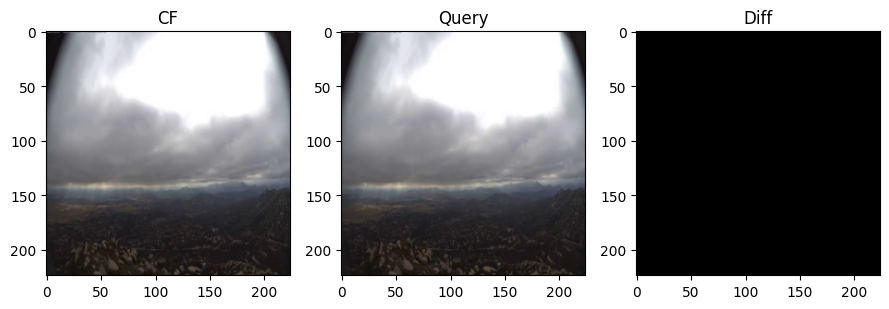

  Schritt 1: probs[fire]=0.0107, probs[no_fire]=0.9893, delta_mean=0.001894, cls=4.5329, dist=0.001330
  Schritt 2: probs[fire]=0.0334, probs[no_fire]=0.9666, delta_mean=0.002754, cls=3.3982, dist=0.002529
  Schritt 3: probs[fire]=0.0941, probs[no_fire]=0.9059, delta_mean=0.003605, cls=2.3630, dist=0.003680
  Schritt 4: probs[fire]=0.2301, probs[no_fire]=0.7699, delta_mean=0.004432, cls=1.4691, dist=0.004814
  Schritt 5: probs[fire]=0.4451, probs[no_fire]=0.5549, delta_mean=0.005224, cls=0.8095, dist=0.005914
  Schritt 6: probs[fire]=0.6614, probs[no_fire]=0.3386, delta_mean=0.005967, cls=0.4134, dist=0.006964
  Schritt 7: probs[fire]=0.8148, probs[no_fire]=0.1852, delta_mean=0.006651, cls=0.2048, dist=0.007947
✓ Zielklasse erreicht | Seed 0 | λ=0.1139 | Schritt 7
λ-Schleife 
7
  Schritt 0: probs[fire]=0.0032, probs[no_fire]=0.9968, delta_mean=0.001000, cls=5.7358, dist=0.000000
Seed 0 | λ=0.1709 | Schritt 000 | Loss: 0.9800 | Pred: no_fire


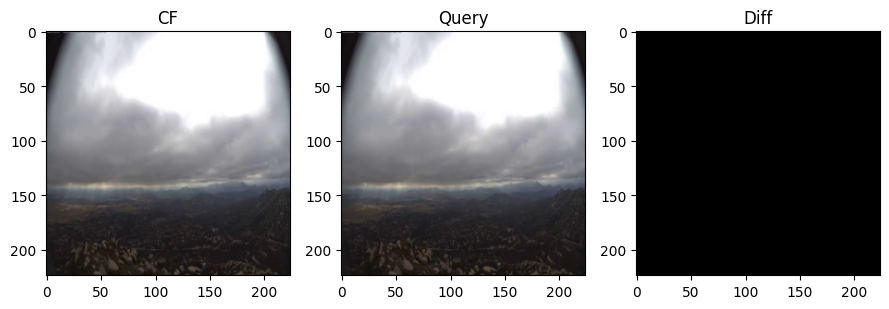

  Schritt 1: probs[fire]=0.0107, probs[no_fire]=0.9893, delta_mean=0.001896, cls=4.5329, dist=0.001330
  Schritt 2: probs[fire]=0.0334, probs[no_fire]=0.9666, delta_mean=0.002759, cls=3.3982, dist=0.002533
  Schritt 3: probs[fire]=0.0941, probs[no_fire]=0.9059, delta_mean=0.003614, cls=2.3631, dist=0.003687
  Schritt 4: probs[fire]=0.2301, probs[no_fire]=0.7699, delta_mean=0.004444, cls=1.4694, dist=0.004825
  Schritt 5: probs[fire]=0.4449, probs[no_fire]=0.5551, delta_mean=0.005239, cls=0.8099, dist=0.005929
  Schritt 6: probs[fire]=0.6613, probs[no_fire]=0.3387, delta_mean=0.005986, cls=0.4136, dist=0.006983
  Schritt 7: probs[fire]=0.8148, probs[no_fire]=0.1852, delta_mean=0.006675, cls=0.2048, dist=0.007972
✓ Zielklasse erreicht | Seed 0 | λ=0.1709 | Schritt 7
λ-Schleife 
8
  Schritt 0: probs[fire]=0.0032, probs[no_fire]=0.9968, delta_mean=0.001000, cls=5.7358, dist=0.000000
Seed 0 | λ=0.2563 | Schritt 000 | Loss: 1.4700 | Pred: no_fire


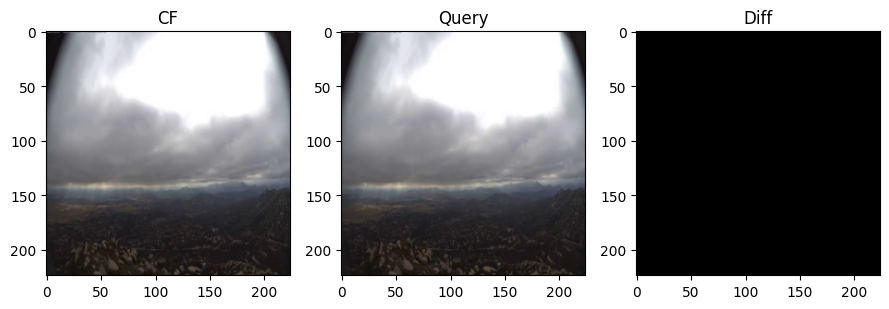

  Schritt 1: probs[fire]=0.0107, probs[no_fire]=0.9893, delta_mean=0.001898, cls=4.5329, dist=0.001330
  Schritt 2: probs[fire]=0.0334, probs[no_fire]=0.9666, delta_mean=0.002763, cls=3.3982, dist=0.002535
  Schritt 3: probs[fire]=0.0941, probs[no_fire]=0.9059, delta_mean=0.003618, cls=2.3631, dist=0.003692
  Schritt 4: probs[fire]=0.2301, probs[no_fire]=0.7699, delta_mean=0.004450, cls=1.4694, dist=0.004832
  Schritt 5: probs[fire]=0.4449, probs[no_fire]=0.5551, delta_mean=0.005247, cls=0.8099, dist=0.005938
  Schritt 6: probs[fire]=0.6613, probs[no_fire]=0.3387, delta_mean=0.005997, cls=0.4135, dist=0.006995
  Schritt 7: probs[fire]=0.8148, probs[no_fire]=0.1852, delta_mean=0.006689, cls=0.2048, dist=0.007987
✓ Zielklasse erreicht | Seed 0 | λ=0.2563 | Schritt 7
λ-Schleife 
9
  Schritt 0: probs[fire]=0.0032, probs[no_fire]=0.9968, delta_mean=0.001000, cls=5.7358, dist=0.000000
Seed 0 | λ=0.3844 | Schritt 000 | Loss: 2.2050 | Pred: no_fire


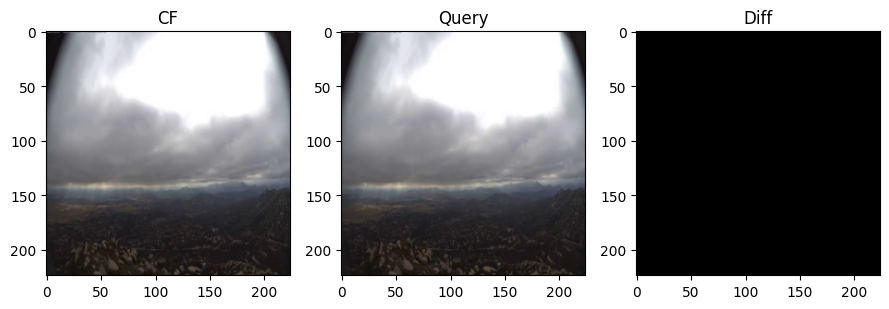

  Schritt 1: probs[fire]=0.0107, probs[no_fire]=0.9893, delta_mean=0.001899, cls=4.5329, dist=0.001331
  Schritt 2: probs[fire]=0.0334, probs[no_fire]=0.9666, delta_mean=0.002765, cls=3.3982, dist=0.002536
  Schritt 3: probs[fire]=0.0941, probs[no_fire]=0.9059, delta_mean=0.003622, cls=2.3631, dist=0.003695
  Schritt 4: probs[fire]=0.2301, probs[no_fire]=0.7699, delta_mean=0.004454, cls=1.4694, dist=0.004836
  Schritt 5: probs[fire]=0.4449, probs[no_fire]=0.5551, delta_mean=0.005253, cls=0.8099, dist=0.005944
  Schritt 6: probs[fire]=0.6613, probs[no_fire]=0.3387, delta_mean=0.006004, cls=0.4135, dist=0.007002
  Schritt 7: probs[fire]=0.8149, probs[no_fire]=0.1851, delta_mean=0.006698, cls=0.2047, dist=0.007996
✓ Zielklasse erreicht | Seed 0 | λ=0.3844 | Schritt 7
→ Neues bestes CF | Seed 0 | Distanz: 1203.6971
Seed 42
λ-Schleife 
0
  Schritt 0: probs[fire]=0.0032, probs[no_fire]=0.9968, delta_mean=0.000999, cls=5.7358, dist=0.000000
Seed 42 | λ=0.0100 | Schritt 000 | Loss: 0.0574 | Pr

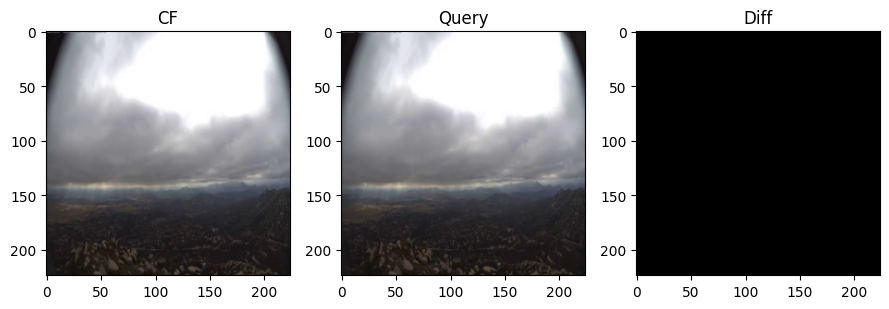

  Schritt 1: probs[fire]=0.0107, probs[no_fire]=0.9893, delta_mean=0.001799, cls=4.5331, dist=0.001329
  Schritt 2: probs[fire]=0.0332, probs[no_fire]=0.9668, delta_mean=0.002565, cls=3.4058, dist=0.002400
  Schritt 3: probs[fire]=0.0928, probs[no_fire]=0.9072, delta_mean=0.003330, cls=2.3776, dist=0.003423
  Schritt 4: probs[fire]=0.2257, probs[no_fire]=0.7743, delta_mean=0.004062, cls=1.4886, dist=0.004438
  Schritt 5: probs[fire]=0.4365, probs[no_fire]=0.5635, delta_mean=0.004746, cls=0.8291, dist=0.005409
  Schritt 6: probs[fire]=0.6503, probs[no_fire]=0.3497, delta_mean=0.005358, cls=0.4304, dist=0.006311
  Schritt 7: probs[fire]=0.8037, probs[no_fire]=0.1963, delta_mean=0.005886, cls=0.2185, dist=0.007118
✓ Zielklasse erreicht | Seed 42 | λ=0.0100 | Schritt 7
λ-Schleife 
1
  Schritt 0: probs[fire]=0.0032, probs[no_fire]=0.9968, delta_mean=0.000999, cls=5.7358, dist=0.000000
Seed 42 | λ=0.0150 | Schritt 000 | Loss: 0.0860 | Pred: no_fire


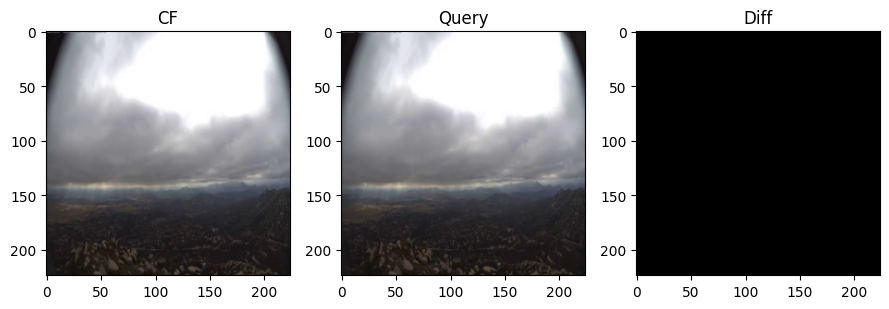

  Schritt 1: probs[fire]=0.0107, probs[no_fire]=0.9893, delta_mean=0.001836, cls=4.5330, dist=0.001330
  Schritt 2: probs[fire]=0.0333, probs[no_fire]=0.9667, delta_mean=0.002638, cls=3.4015, dist=0.002450
  Schritt 3: probs[fire]=0.0936, probs[no_fire]=0.9064, delta_mean=0.003435, cls=2.3691, dist=0.003521
  Schritt 4: probs[fire]=0.2283, probs[no_fire]=0.7717, delta_mean=0.004205, cls=1.4773, dist=0.004582
  Schritt 5: probs[fire]=0.4415, probs[no_fire]=0.5585, delta_mean=0.004930, cls=0.8176, dist=0.005602
  Schritt 6: probs[fire]=0.6566, probs[no_fire]=0.3434, delta_mean=0.005590, cls=0.4207, dist=0.006561
  Schritt 7: probs[fire]=0.8098, probs[no_fire]=0.1902, delta_mean=0.006172, cls=0.2110, dist=0.007431
✓ Zielklasse erreicht | Seed 42 | λ=0.0150 | Schritt 7
λ-Schleife 
2
  Schritt 0: probs[fire]=0.0032, probs[no_fire]=0.9968, delta_mean=0.000999, cls=5.7358, dist=0.000000
Seed 42 | λ=0.0225 | Schritt 000 | Loss: 0.1291 | Pred: no_fire


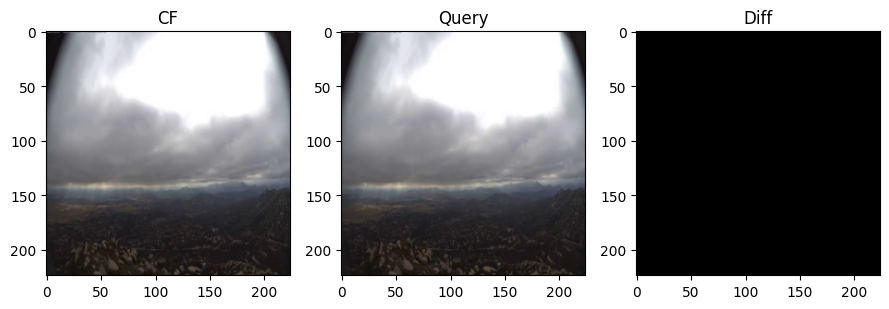

  Schritt 1: probs[fire]=0.0107, probs[no_fire]=0.9893, delta_mean=0.001859, cls=4.5330, dist=0.001330
  Schritt 2: probs[fire]=0.0334, probs[no_fire]=0.9666, delta_mean=0.002685, cls=3.3996, dist=0.002482
  Schritt 3: probs[fire]=0.0939, probs[no_fire]=0.9061, delta_mean=0.003504, cls=2.3654, dist=0.003586
  Schritt 4: probs[fire]=0.2294, probs[no_fire]=0.7706, delta_mean=0.004297, cls=1.4724, dist=0.004676
  Schritt 5: probs[fire]=0.4435, probs[no_fire]=0.5565, delta_mean=0.005048, cls=0.8130, dist=0.005728
  Schritt 6: probs[fire]=0.6592, probs[no_fire]=0.3408, delta_mean=0.005740, cls=0.4167, dist=0.006722
  Schritt 7: probs[fire]=0.8124, probs[no_fire]=0.1876, delta_mean=0.006361, cls=0.2077, dist=0.007635
✓ Zielklasse erreicht | Seed 42 | λ=0.0225 | Schritt 7
λ-Schleife 
3
  Schritt 0: probs[fire]=0.0032, probs[no_fire]=0.9968, delta_mean=0.001000, cls=5.7358, dist=0.000000
Seed 42 | λ=0.0338 | Schritt 000 | Loss: 0.1936 | Pred: no_fire


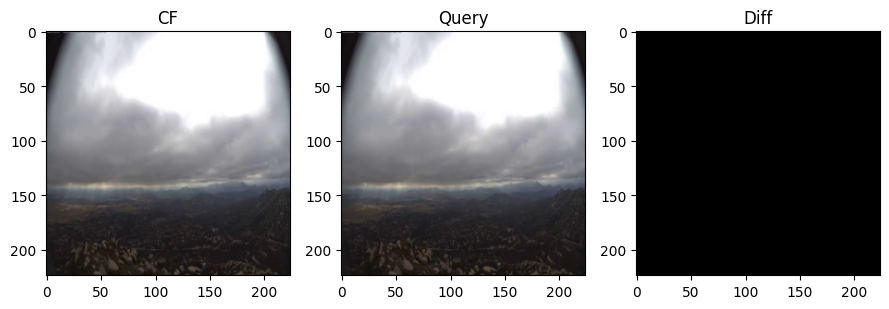

  Schritt 1: probs[fire]=0.0107, probs[no_fire]=0.9893, delta_mean=0.001874, cls=4.5330, dist=0.001330
  Schritt 2: probs[fire]=0.0334, probs[no_fire]=0.9666, delta_mean=0.002716, cls=3.3987, dist=0.002503
  Schritt 3: probs[fire]=0.0941, probs[no_fire]=0.9059, delta_mean=0.003549, cls=2.3639, dist=0.003628
  Schritt 4: probs[fire]=0.2298, probs[no_fire]=0.7702, delta_mean=0.004356, cls=1.4704, dist=0.004737
  Schritt 5: probs[fire]=0.4444, probs[no_fire]=0.5556, delta_mean=0.005125, cls=0.8110, dist=0.005809
  Schritt 6: probs[fire]=0.6604, probs[no_fire]=0.3396, delta_mean=0.005839, cls=0.4148, dist=0.006827
  Schritt 7: probs[fire]=0.8137, probs[no_fire]=0.1863, delta_mean=0.006485, cls=0.2061, dist=0.007770
✓ Zielklasse erreicht | Seed 42 | λ=0.0338 | Schritt 7
λ-Schleife 
4
  Schritt 0: probs[fire]=0.0032, probs[no_fire]=0.9968, delta_mean=0.001000, cls=5.7358, dist=0.000000
Seed 42 | λ=0.0506 | Schritt 000 | Loss: 0.2904 | Pred: no_fire


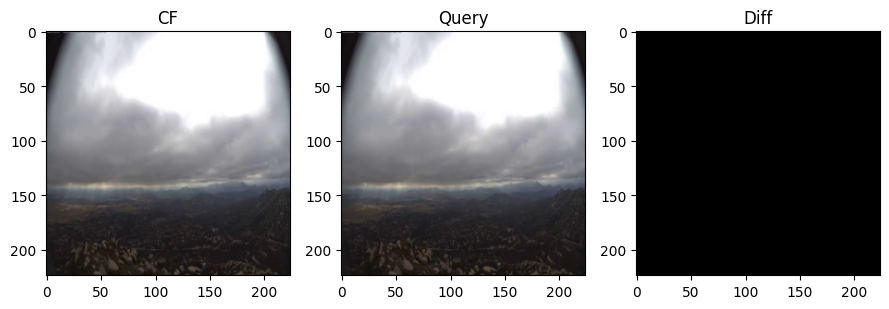

  Schritt 1: probs[fire]=0.0107, probs[no_fire]=0.9893, delta_mean=0.001884, cls=4.5329, dist=0.001330
  Schritt 2: probs[fire]=0.0334, probs[no_fire]=0.9666, delta_mean=0.002735, cls=3.3984, dist=0.002516
  Schritt 3: probs[fire]=0.0941, probs[no_fire]=0.9059, delta_mean=0.003576, cls=2.3633, dist=0.003653
  Schritt 4: probs[fire]=0.2300, probs[no_fire]=0.7700, delta_mean=0.004394, cls=1.4695, dist=0.004775
  Schritt 5: probs[fire]=0.4449, probs[no_fire]=0.5551, delta_mean=0.005174, cls=0.8100, dist=0.005861
  Schritt 6: probs[fire]=0.6611, probs[no_fire]=0.3389, delta_mean=0.005901, cls=0.4139, dist=0.006894
  Schritt 7: probs[fire]=0.8144, probs[no_fire]=0.1856, delta_mean=0.006566, cls=0.2053, dist=0.007856
✓ Zielklasse erreicht | Seed 42 | λ=0.0506 | Schritt 7
λ-Schleife 
5
  Schritt 0: probs[fire]=0.0032, probs[no_fire]=0.9968, delta_mean=0.001000, cls=5.7358, dist=0.000000
Seed 42 | λ=0.0759 | Schritt 000 | Loss: 0.4356 | Pred: no_fire


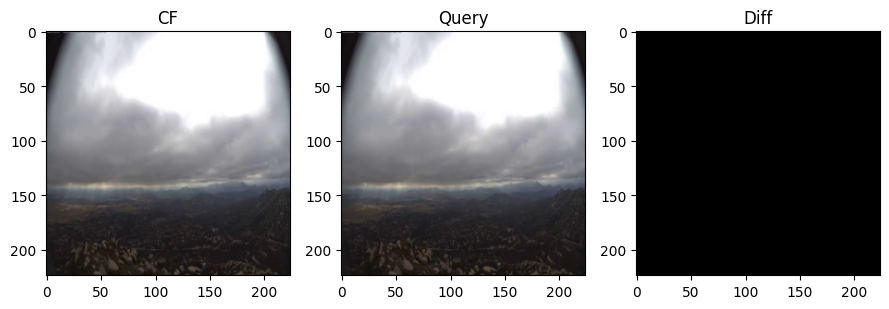

  Schritt 1: probs[fire]=0.0107, probs[no_fire]=0.9893, delta_mean=0.001890, cls=4.5329, dist=0.001330
  Schritt 2: probs[fire]=0.0334, probs[no_fire]=0.9666, delta_mean=0.002747, cls=3.3983, dist=0.002524
  Schritt 3: probs[fire]=0.0941, probs[no_fire]=0.9059, delta_mean=0.003594, cls=2.3631, dist=0.003670
  Schritt 4: probs[fire]=0.2301, probs[no_fire]=0.7699, delta_mean=0.004417, cls=1.4692, dist=0.004799
  Schritt 5: probs[fire]=0.4450, probs[no_fire]=0.5550, delta_mean=0.005204, cls=0.8097, dist=0.005893
  Schritt 6: probs[fire]=0.6613, probs[no_fire]=0.3387, delta_mean=0.005941, cls=0.4136, dist=0.006936
  Schritt 7: probs[fire]=0.8146, probs[no_fire]=0.1854, delta_mean=0.006617, cls=0.2050, dist=0.007912
✓ Zielklasse erreicht | Seed 42 | λ=0.0759 | Schritt 7
λ-Schleife 
6
  Schritt 0: probs[fire]=0.0032, probs[no_fire]=0.9968, delta_mean=0.001000, cls=5.7358, dist=0.000000
Seed 42 | λ=0.1139 | Schritt 000 | Loss: 0.6533 | Pred: no_fire


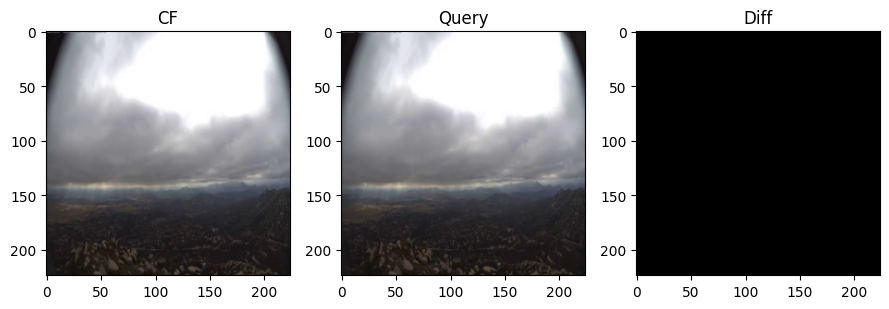

  Schritt 1: probs[fire]=0.0107, probs[no_fire]=0.9893, delta_mean=0.001894, cls=4.5329, dist=0.001330
  Schritt 2: probs[fire]=0.0334, probs[no_fire]=0.9666, delta_mean=0.002754, cls=3.3982, dist=0.002529
  Schritt 3: probs[fire]=0.0941, probs[no_fire]=0.9059, delta_mean=0.003605, cls=2.3630, dist=0.003680
  Schritt 4: probs[fire]=0.2301, probs[no_fire]=0.7699, delta_mean=0.004432, cls=1.4691, dist=0.004814
  Schritt 5: probs[fire]=0.4451, probs[no_fire]=0.5549, delta_mean=0.005224, cls=0.8095, dist=0.005914
  Schritt 6: probs[fire]=0.6614, probs[no_fire]=0.3386, delta_mean=0.005967, cls=0.4134, dist=0.006964
  Schritt 7: probs[fire]=0.8148, probs[no_fire]=0.1852, delta_mean=0.006651, cls=0.2048, dist=0.007947
✓ Zielklasse erreicht | Seed 42 | λ=0.1139 | Schritt 7
λ-Schleife 
7
  Schritt 0: probs[fire]=0.0032, probs[no_fire]=0.9968, delta_mean=0.001000, cls=5.7358, dist=0.000000
Seed 42 | λ=0.1709 | Schritt 000 | Loss: 0.9800 | Pred: no_fire


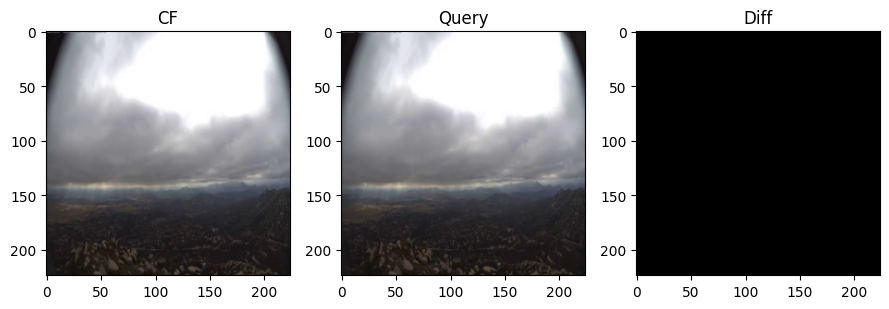

  Schritt 1: probs[fire]=0.0107, probs[no_fire]=0.9893, delta_mean=0.001896, cls=4.5329, dist=0.001330
  Schritt 2: probs[fire]=0.0334, probs[no_fire]=0.9666, delta_mean=0.002759, cls=3.3982, dist=0.002533
  Schritt 3: probs[fire]=0.0941, probs[no_fire]=0.9059, delta_mean=0.003614, cls=2.3631, dist=0.003687
  Schritt 4: probs[fire]=0.2301, probs[no_fire]=0.7699, delta_mean=0.004444, cls=1.4694, dist=0.004825
  Schritt 5: probs[fire]=0.4449, probs[no_fire]=0.5551, delta_mean=0.005239, cls=0.8099, dist=0.005929
  Schritt 6: probs[fire]=0.6613, probs[no_fire]=0.3387, delta_mean=0.005986, cls=0.4136, dist=0.006983
  Schritt 7: probs[fire]=0.8148, probs[no_fire]=0.1852, delta_mean=0.006675, cls=0.2048, dist=0.007972
✓ Zielklasse erreicht | Seed 42 | λ=0.1709 | Schritt 7
λ-Schleife 
8
  Schritt 0: probs[fire]=0.0032, probs[no_fire]=0.9968, delta_mean=0.001000, cls=5.7358, dist=0.000000
Seed 42 | λ=0.2563 | Schritt 000 | Loss: 1.4700 | Pred: no_fire


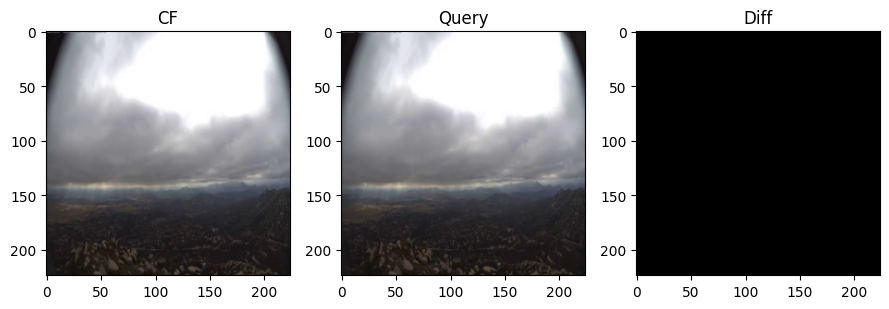

  Schritt 1: probs[fire]=0.0107, probs[no_fire]=0.9893, delta_mean=0.001898, cls=4.5329, dist=0.001330
  Schritt 2: probs[fire]=0.0334, probs[no_fire]=0.9666, delta_mean=0.002763, cls=3.3982, dist=0.002535
  Schritt 3: probs[fire]=0.0941, probs[no_fire]=0.9059, delta_mean=0.003618, cls=2.3631, dist=0.003692
  Schritt 4: probs[fire]=0.2301, probs[no_fire]=0.7699, delta_mean=0.004450, cls=1.4694, dist=0.004832
  Schritt 5: probs[fire]=0.4449, probs[no_fire]=0.5551, delta_mean=0.005247, cls=0.8099, dist=0.005938
  Schritt 6: probs[fire]=0.6613, probs[no_fire]=0.3387, delta_mean=0.005997, cls=0.4135, dist=0.006995
  Schritt 7: probs[fire]=0.8148, probs[no_fire]=0.1852, delta_mean=0.006689, cls=0.2048, dist=0.007987
✓ Zielklasse erreicht | Seed 42 | λ=0.2563 | Schritt 7
λ-Schleife 
9
  Schritt 0: probs[fire]=0.0032, probs[no_fire]=0.9968, delta_mean=0.001000, cls=5.7358, dist=0.000000
Seed 42 | λ=0.3844 | Schritt 000 | Loss: 2.2050 | Pred: no_fire


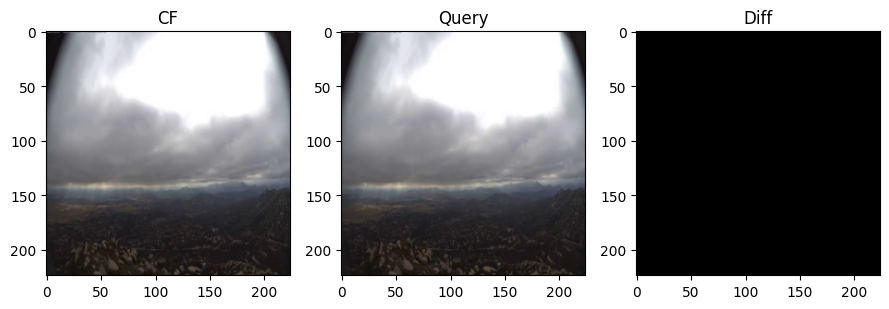

  Schritt 1: probs[fire]=0.0107, probs[no_fire]=0.9893, delta_mean=0.001899, cls=4.5329, dist=0.001331
  Schritt 2: probs[fire]=0.0334, probs[no_fire]=0.9666, delta_mean=0.002765, cls=3.3982, dist=0.002536
  Schritt 3: probs[fire]=0.0941, probs[no_fire]=0.9059, delta_mean=0.003622, cls=2.3631, dist=0.003695
  Schritt 4: probs[fire]=0.2301, probs[no_fire]=0.7699, delta_mean=0.004454, cls=1.4694, dist=0.004836
  Schritt 5: probs[fire]=0.4449, probs[no_fire]=0.5551, delta_mean=0.005253, cls=0.8099, dist=0.005944
  Schritt 6: probs[fire]=0.6613, probs[no_fire]=0.3387, delta_mean=0.006004, cls=0.4135, dist=0.007002
  Schritt 7: probs[fire]=0.8149, probs[no_fire]=0.1851, delta_mean=0.006698, cls=0.2047, dist=0.007996
✓ Zielklasse erreicht | Seed 42 | λ=0.3844 | Schritt 7
Seed 123
λ-Schleife 
0
  Schritt 0: probs[fire]=0.0032, probs[no_fire]=0.9968, delta_mean=0.000999, cls=5.7358, dist=0.000000
Seed 123 | λ=0.0100 | Schritt 000 | Loss: 0.0574 | Pred: no_fire


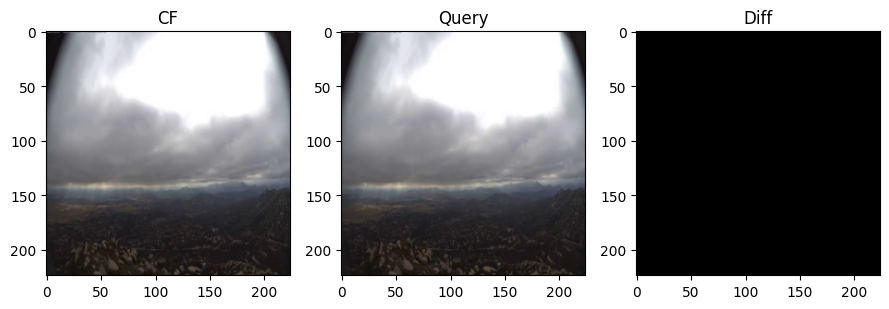

  Schritt 1: probs[fire]=0.0107, probs[no_fire]=0.9893, delta_mean=0.001799, cls=4.5331, dist=0.001329
  Schritt 2: probs[fire]=0.0332, probs[no_fire]=0.9668, delta_mean=0.002565, cls=3.4058, dist=0.002400
  Schritt 3: probs[fire]=0.0928, probs[no_fire]=0.9072, delta_mean=0.003330, cls=2.3776, dist=0.003423
  Schritt 4: probs[fire]=0.2257, probs[no_fire]=0.7743, delta_mean=0.004062, cls=1.4886, dist=0.004438
  Schritt 5: probs[fire]=0.4365, probs[no_fire]=0.5635, delta_mean=0.004746, cls=0.8291, dist=0.005409
  Schritt 6: probs[fire]=0.6503, probs[no_fire]=0.3497, delta_mean=0.005358, cls=0.4304, dist=0.006311
  Schritt 7: probs[fire]=0.8037, probs[no_fire]=0.1963, delta_mean=0.005886, cls=0.2185, dist=0.007118
✓ Zielklasse erreicht | Seed 123 | λ=0.0100 | Schritt 7
λ-Schleife 
1
  Schritt 0: probs[fire]=0.0032, probs[no_fire]=0.9968, delta_mean=0.000999, cls=5.7358, dist=0.000000
Seed 123 | λ=0.0150 | Schritt 000 | Loss: 0.0860 | Pred: no_fire


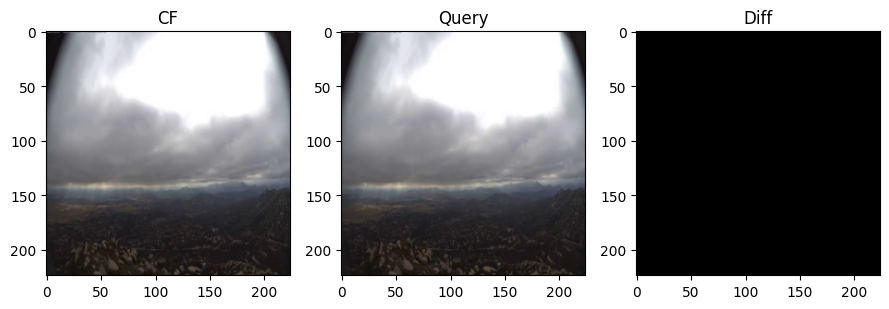

  Schritt 1: probs[fire]=0.0107, probs[no_fire]=0.9893, delta_mean=0.001836, cls=4.5330, dist=0.001330
  Schritt 2: probs[fire]=0.0333, probs[no_fire]=0.9667, delta_mean=0.002638, cls=3.4015, dist=0.002450
  Schritt 3: probs[fire]=0.0936, probs[no_fire]=0.9064, delta_mean=0.003435, cls=2.3691, dist=0.003521
  Schritt 4: probs[fire]=0.2283, probs[no_fire]=0.7717, delta_mean=0.004205, cls=1.4773, dist=0.004582
  Schritt 5: probs[fire]=0.4415, probs[no_fire]=0.5585, delta_mean=0.004930, cls=0.8176, dist=0.005602
  Schritt 6: probs[fire]=0.6566, probs[no_fire]=0.3434, delta_mean=0.005590, cls=0.4207, dist=0.006561
  Schritt 7: probs[fire]=0.8098, probs[no_fire]=0.1902, delta_mean=0.006172, cls=0.2110, dist=0.007431
✓ Zielklasse erreicht | Seed 123 | λ=0.0150 | Schritt 7
λ-Schleife 
2
  Schritt 0: probs[fire]=0.0032, probs[no_fire]=0.9968, delta_mean=0.000999, cls=5.7358, dist=0.000000
Seed 123 | λ=0.0225 | Schritt 000 | Loss: 0.1291 | Pred: no_fire


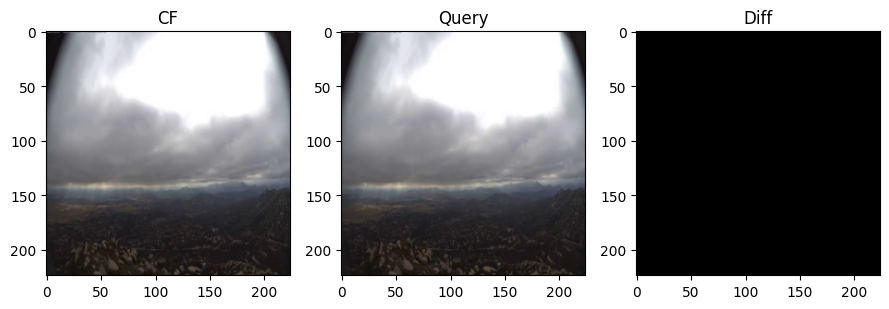

  Schritt 1: probs[fire]=0.0107, probs[no_fire]=0.9893, delta_mean=0.001859, cls=4.5330, dist=0.001330
  Schritt 2: probs[fire]=0.0334, probs[no_fire]=0.9666, delta_mean=0.002685, cls=3.3996, dist=0.002482
  Schritt 3: probs[fire]=0.0939, probs[no_fire]=0.9061, delta_mean=0.003504, cls=2.3654, dist=0.003586
  Schritt 4: probs[fire]=0.2294, probs[no_fire]=0.7706, delta_mean=0.004297, cls=1.4724, dist=0.004676
  Schritt 5: probs[fire]=0.4435, probs[no_fire]=0.5565, delta_mean=0.005048, cls=0.8130, dist=0.005728
  Schritt 6: probs[fire]=0.6592, probs[no_fire]=0.3408, delta_mean=0.005740, cls=0.4167, dist=0.006722
  Schritt 7: probs[fire]=0.8124, probs[no_fire]=0.1876, delta_mean=0.006361, cls=0.2077, dist=0.007635
✓ Zielklasse erreicht | Seed 123 | λ=0.0225 | Schritt 7
λ-Schleife 
3
  Schritt 0: probs[fire]=0.0032, probs[no_fire]=0.9968, delta_mean=0.001000, cls=5.7358, dist=0.000000
Seed 123 | λ=0.0338 | Schritt 000 | Loss: 0.1936 | Pred: no_fire


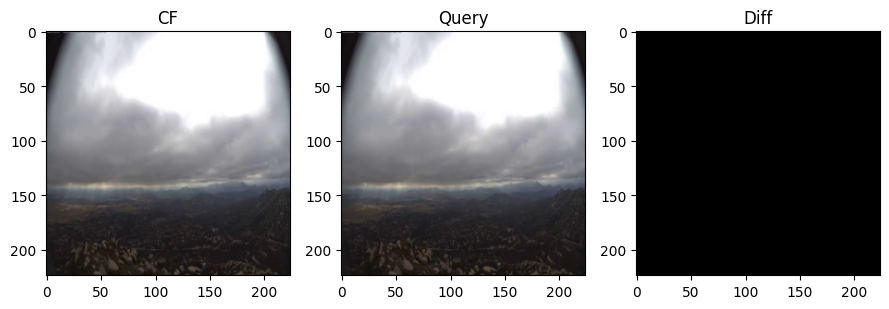

  Schritt 1: probs[fire]=0.0107, probs[no_fire]=0.9893, delta_mean=0.001874, cls=4.5330, dist=0.001330
  Schritt 2: probs[fire]=0.0334, probs[no_fire]=0.9666, delta_mean=0.002716, cls=3.3987, dist=0.002503
  Schritt 3: probs[fire]=0.0941, probs[no_fire]=0.9059, delta_mean=0.003549, cls=2.3639, dist=0.003628
  Schritt 4: probs[fire]=0.2298, probs[no_fire]=0.7702, delta_mean=0.004356, cls=1.4704, dist=0.004737
  Schritt 5: probs[fire]=0.4444, probs[no_fire]=0.5556, delta_mean=0.005125, cls=0.8110, dist=0.005809
  Schritt 6: probs[fire]=0.6604, probs[no_fire]=0.3396, delta_mean=0.005839, cls=0.4148, dist=0.006827
  Schritt 7: probs[fire]=0.8137, probs[no_fire]=0.1863, delta_mean=0.006485, cls=0.2061, dist=0.007770
✓ Zielklasse erreicht | Seed 123 | λ=0.0338 | Schritt 7
λ-Schleife 
4
  Schritt 0: probs[fire]=0.0032, probs[no_fire]=0.9968, delta_mean=0.001000, cls=5.7358, dist=0.000000
Seed 123 | λ=0.0506 | Schritt 000 | Loss: 0.2904 | Pred: no_fire


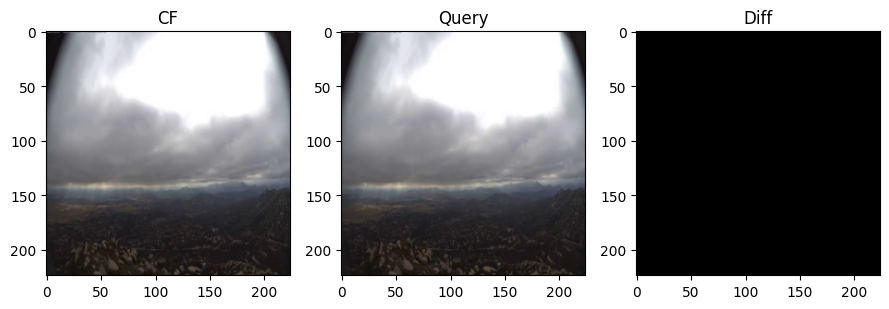

  Schritt 1: probs[fire]=0.0107, probs[no_fire]=0.9893, delta_mean=0.001884, cls=4.5329, dist=0.001330
  Schritt 2: probs[fire]=0.0334, probs[no_fire]=0.9666, delta_mean=0.002735, cls=3.3984, dist=0.002516
  Schritt 3: probs[fire]=0.0941, probs[no_fire]=0.9059, delta_mean=0.003576, cls=2.3633, dist=0.003653
  Schritt 4: probs[fire]=0.2300, probs[no_fire]=0.7700, delta_mean=0.004394, cls=1.4695, dist=0.004775
  Schritt 5: probs[fire]=0.4449, probs[no_fire]=0.5551, delta_mean=0.005174, cls=0.8100, dist=0.005861
  Schritt 6: probs[fire]=0.6611, probs[no_fire]=0.3389, delta_mean=0.005901, cls=0.4139, dist=0.006894
  Schritt 7: probs[fire]=0.8144, probs[no_fire]=0.1856, delta_mean=0.006566, cls=0.2053, dist=0.007856
✓ Zielklasse erreicht | Seed 123 | λ=0.0506 | Schritt 7
λ-Schleife 
5
  Schritt 0: probs[fire]=0.0032, probs[no_fire]=0.9968, delta_mean=0.001000, cls=5.7358, dist=0.000000
Seed 123 | λ=0.0759 | Schritt 000 | Loss: 0.4356 | Pred: no_fire


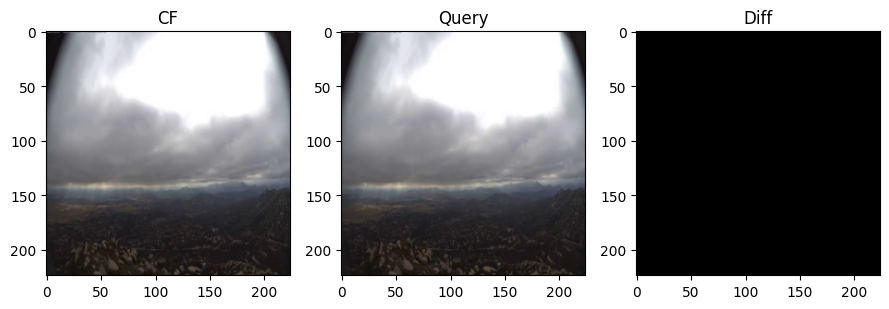

  Schritt 1: probs[fire]=0.0107, probs[no_fire]=0.9893, delta_mean=0.001890, cls=4.5329, dist=0.001330
  Schritt 2: probs[fire]=0.0334, probs[no_fire]=0.9666, delta_mean=0.002747, cls=3.3983, dist=0.002524
  Schritt 3: probs[fire]=0.0941, probs[no_fire]=0.9059, delta_mean=0.003594, cls=2.3631, dist=0.003670
  Schritt 4: probs[fire]=0.2301, probs[no_fire]=0.7699, delta_mean=0.004417, cls=1.4692, dist=0.004799
  Schritt 5: probs[fire]=0.4450, probs[no_fire]=0.5550, delta_mean=0.005204, cls=0.8097, dist=0.005893
  Schritt 6: probs[fire]=0.6613, probs[no_fire]=0.3387, delta_mean=0.005941, cls=0.4136, dist=0.006936
  Schritt 7: probs[fire]=0.8146, probs[no_fire]=0.1854, delta_mean=0.006617, cls=0.2050, dist=0.007912
✓ Zielklasse erreicht | Seed 123 | λ=0.0759 | Schritt 7
λ-Schleife 
6
  Schritt 0: probs[fire]=0.0032, probs[no_fire]=0.9968, delta_mean=0.001000, cls=5.7358, dist=0.000000
Seed 123 | λ=0.1139 | Schritt 000 | Loss: 0.6533 | Pred: no_fire


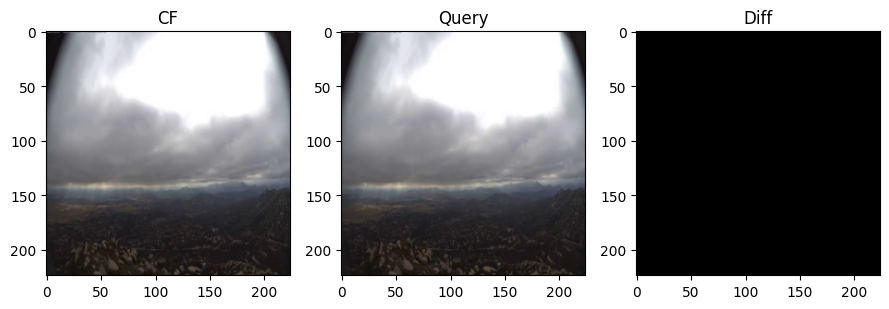

  Schritt 1: probs[fire]=0.0107, probs[no_fire]=0.9893, delta_mean=0.001894, cls=4.5329, dist=0.001330
  Schritt 2: probs[fire]=0.0334, probs[no_fire]=0.9666, delta_mean=0.002754, cls=3.3982, dist=0.002529
  Schritt 3: probs[fire]=0.0941, probs[no_fire]=0.9059, delta_mean=0.003605, cls=2.3630, dist=0.003680
  Schritt 4: probs[fire]=0.2301, probs[no_fire]=0.7699, delta_mean=0.004432, cls=1.4691, dist=0.004814
  Schritt 5: probs[fire]=0.4451, probs[no_fire]=0.5549, delta_mean=0.005224, cls=0.8095, dist=0.005914
  Schritt 6: probs[fire]=0.6614, probs[no_fire]=0.3386, delta_mean=0.005967, cls=0.4134, dist=0.006964
  Schritt 7: probs[fire]=0.8148, probs[no_fire]=0.1852, delta_mean=0.006651, cls=0.2048, dist=0.007947
✓ Zielklasse erreicht | Seed 123 | λ=0.1139 | Schritt 7
λ-Schleife 
7
  Schritt 0: probs[fire]=0.0032, probs[no_fire]=0.9968, delta_mean=0.001000, cls=5.7358, dist=0.000000
Seed 123 | λ=0.1709 | Schritt 000 | Loss: 0.9800 | Pred: no_fire


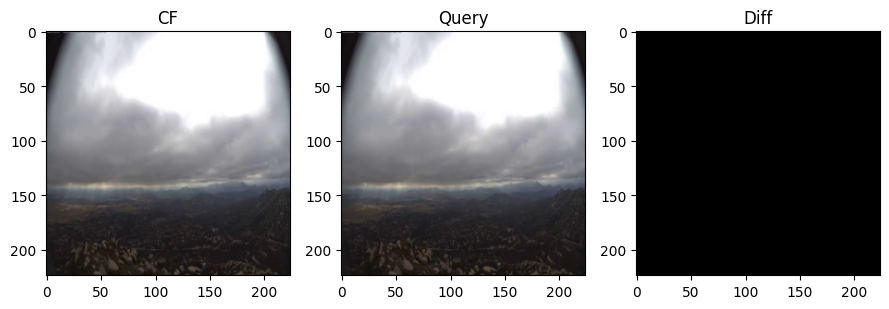

  Schritt 1: probs[fire]=0.0107, probs[no_fire]=0.9893, delta_mean=0.001896, cls=4.5329, dist=0.001330
  Schritt 2: probs[fire]=0.0334, probs[no_fire]=0.9666, delta_mean=0.002759, cls=3.3982, dist=0.002533
  Schritt 3: probs[fire]=0.0941, probs[no_fire]=0.9059, delta_mean=0.003614, cls=2.3631, dist=0.003687
  Schritt 4: probs[fire]=0.2301, probs[no_fire]=0.7699, delta_mean=0.004444, cls=1.4694, dist=0.004825
  Schritt 5: probs[fire]=0.4449, probs[no_fire]=0.5551, delta_mean=0.005239, cls=0.8099, dist=0.005929
  Schritt 6: probs[fire]=0.6613, probs[no_fire]=0.3387, delta_mean=0.005986, cls=0.4136, dist=0.006983
  Schritt 7: probs[fire]=0.8148, probs[no_fire]=0.1852, delta_mean=0.006675, cls=0.2048, dist=0.007972
✓ Zielklasse erreicht | Seed 123 | λ=0.1709 | Schritt 7
λ-Schleife 
8
  Schritt 0: probs[fire]=0.0032, probs[no_fire]=0.9968, delta_mean=0.001000, cls=5.7358, dist=0.000000
Seed 123 | λ=0.2563 | Schritt 000 | Loss: 1.4700 | Pred: no_fire


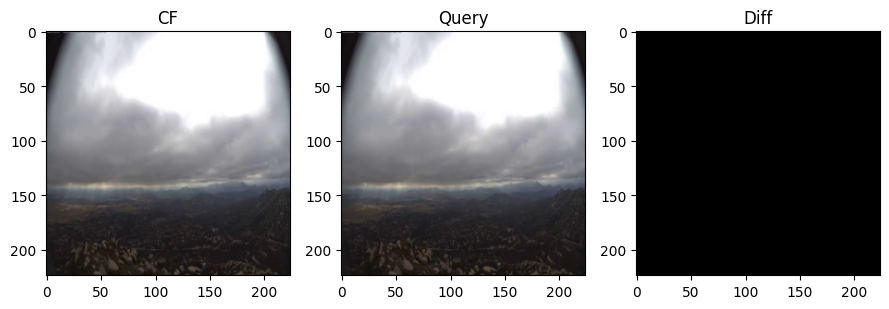

  Schritt 1: probs[fire]=0.0107, probs[no_fire]=0.9893, delta_mean=0.001898, cls=4.5329, dist=0.001330
  Schritt 2: probs[fire]=0.0334, probs[no_fire]=0.9666, delta_mean=0.002763, cls=3.3982, dist=0.002535
  Schritt 3: probs[fire]=0.0941, probs[no_fire]=0.9059, delta_mean=0.003618, cls=2.3631, dist=0.003692
  Schritt 4: probs[fire]=0.2301, probs[no_fire]=0.7699, delta_mean=0.004450, cls=1.4694, dist=0.004832
  Schritt 5: probs[fire]=0.4449, probs[no_fire]=0.5551, delta_mean=0.005247, cls=0.8099, dist=0.005938
  Schritt 6: probs[fire]=0.6613, probs[no_fire]=0.3387, delta_mean=0.005997, cls=0.4135, dist=0.006995
  Schritt 7: probs[fire]=0.8148, probs[no_fire]=0.1852, delta_mean=0.006689, cls=0.2048, dist=0.007987
✓ Zielklasse erreicht | Seed 123 | λ=0.2563 | Schritt 7
λ-Schleife 
9
  Schritt 0: probs[fire]=0.0032, probs[no_fire]=0.9968, delta_mean=0.001000, cls=5.7358, dist=0.000000
Seed 123 | λ=0.3844 | Schritt 000 | Loss: 2.2050 | Pred: no_fire


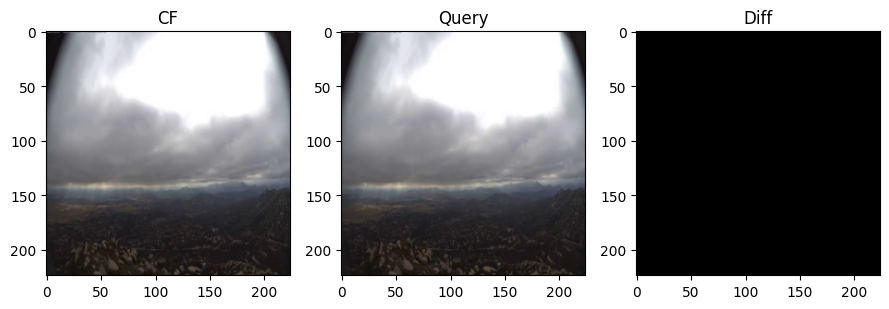

  Schritt 1: probs[fire]=0.0107, probs[no_fire]=0.9893, delta_mean=0.001899, cls=4.5329, dist=0.001331
  Schritt 2: probs[fire]=0.0334, probs[no_fire]=0.9666, delta_mean=0.002765, cls=3.3982, dist=0.002536
  Schritt 3: probs[fire]=0.0941, probs[no_fire]=0.9059, delta_mean=0.003622, cls=2.3631, dist=0.003695
  Schritt 4: probs[fire]=0.2301, probs[no_fire]=0.7699, delta_mean=0.004454, cls=1.4694, dist=0.004836
  Schritt 5: probs[fire]=0.4449, probs[no_fire]=0.5551, delta_mean=0.005253, cls=0.8099, dist=0.005944
  Schritt 6: probs[fire]=0.6613, probs[no_fire]=0.3387, delta_mean=0.006004, cls=0.4135, dist=0.007002
  Schritt 7: probs[fire]=0.8149, probs[no_fire]=0.1851, delta_mean=0.006698, cls=0.2047, dist=0.007996
✓ Zielklasse erreicht | Seed 123 | λ=0.3844 | Schritt 7

Bestes CF | Gesamtdistanz: 1203.6971
Finale Vorhersage: fire


In [14]:
print(MODEL_SAVE_PATH)

def denormalize(tensor, mean=IMAGENET_MEAN, std=IMAGENET_STD):
    t = tensor.clone().cpu()
    for c, (m, s) in enumerate(zip(mean, std)):
        t[c] = t[c] * s + m
    return t.clamp(0, 1)

def load_model(path, device):
    global model
    model = resnet18(in_channels=3, n_classes=n_classes)
    checkpoint = torch.load(path, map_location=device)
    model.load_state_dict(checkpoint['model_state_dict'])
    model.to(device)
    model.eval()
    return model

# 1. Dataset & Modell laden 
train_loader, val_loader, cf_train_set, class_names, n_classes = get_dataloaders(
    data_dir=OUTPUT_DIR,
    batch_size=BATCH_SIZE,
    val_split=VAL_SPLIT,
    num_workers=NUM_WORKERS
)
load_model(MODEL_SAVE_PATH, device)

# Gewichte einfrieren 
for param in model.parameters():
    param.requires_grad = False

# 2. Query-Bild wählen 
# Query-Sampling – nur Bilder wählen die das Modell korrekt und mit hoher Konfidenz klassifiziert
while True:
    query_image, query_label = cf_train_set[randint(0, len(cf_train_set) - 1)]
    query_image_dev = query_image.clone().to(device)
    
    with torch.no_grad():
        output = model(query_image_dev.unsqueeze(0))
        probs  = torch.softmax(output, dim=1)
        pred   = output.argmax().item()
        conf   = probs[0, query_label].item()
    
    # Modell muss das Query korrekt klassifizieren mit Konfidenz > 0.9
    if pred == query_label and conf > 0.9:
        break

query_image = query_image_dev
n_pixels    = query_image.numel()
print(f'Query Label: {query_label} ({class_names[query_label]}) | Konfidenz: {conf:.4f}')

cf_target = 1 - query_label
print(f'CF Target: {cf_target} ({class_names[cf_target]})')

# 3. MAD einmalig berechnen 
print("MAD")
print(len(cf_train_set))
sample_idx = sample(range(len(cf_train_set)), 1000)
all_pixels = torch.stack([cf_train_set[i][0] for i in sample_idx])
median     = all_pixels.median(dim=0).values
mad        = (all_pixels - median).abs().median(dim=0).values
mad        = mad.clamp(min=1e-6).to(device)
print("NO MAD")
# 4. Hyperparameter 
error                = nn.CrossEntropyLoss()
learning_rate        = 0.001
lambda_val           = 0.01
lambda_step          = 1.5
confidence_threshold = 0.8

seeds     = [0, 42, 123]
best_cf   = None
best_dist = float('inf')

#  5. Seed-Schleife (äußerste) 
for seed in seeds:
    torch.manual_seed(seed)
    lambda_val = 0.01  
    print('Seed', seed)
    #  6. λ-Schleife 
    for outer in range(10):
        print('λ-Schleife ')
        print(outer)
        delta = torch.zeros_like(query_image, requires_grad=True)
        optimizer_cf = torch.optim.Adam([delta], lr=learning_rate)

#  7. Optimierungsschleife (innerste) 
        for i in range(1000):
            optimizer_cf.zero_grad()
            cf_image = query_image + delta
            output   = model(cf_image.unsqueeze(0))
            probs    = torch.softmax(output, dim=1)
            dist    = ((cf_image - query_image).abs() / mad).sum() / n_pixels
            cls     = error(output, torch.tensor([cf_target]).to(device))
            loss_cf = lambda_val * cls + dist
            loss_cf.backward()
            optimizer_cf.step()

 
            if i < 15:
                print(f"  Schritt {i}: probs[fire]={probs[0,0].item():.4f}, "
                      f"probs[no_fire]={probs[0,1].item():.4f}, "
                      f"delta_mean={delta.abs().mean().item():.6f}, "
                      f"cls={cls.item():.4f}, dist={dist.item():.6f}")

            if i % 100 == 0:
                pred = output.argmax().item()
                print(f"Seed {seed} | λ={lambda_val:.4f} | Schritt {i:03d} | "
                      f"Loss: {loss_cf.item():.4f} | Pred: {class_names[pred]}")

                fig, axes = plt.subplots(1, 3, figsize=(9, 3))
                cf_np     = denormalize(cf_image.detach().cpu()).numpy()
                query_np  = denormalize(query_image.cpu()).numpy()
                diff_display = np.abs(cf_np - query_np)
                diff_display = diff_display - diff_display.min()
                if diff_display.max() > 0:
                    diff_display = diff_display / diff_display.max()

                def to_display(t):
                    return t[0] if t.shape[0] == 1 else t.transpose(1, 2, 0)

                axes[0].imshow(to_display(cf_np));    axes[0].set_title("CF")
                axes[1].imshow(to_display(query_np)); axes[1].set_title("Query")
                axes[2].imshow(to_display(diff_display)); axes[2].set_title("Diff")
                plt.tight_layout()
                plt.show()

            if probs[0, cf_target].item() >= confidence_threshold:
                print(f"✓ Zielklasse erreicht | Seed {seed} | λ={lambda_val:.4f} | Schritt {i}")
                break

        lambda_val *= lambda_step

    #  8. Bestes CF speichern 
    current_dist = ((cf_image - query_image).abs() / mad).sum().item()
    if current_dist < best_dist:
        best_dist = current_dist
        best_cf   = cf_image.detach().clone()
        print(f"→ Neues bestes CF | Seed {seed} | Distanz: {best_dist:.4f}")

print(f"\nBestes CF | Gesamtdistanz: {best_dist:.4f}")
print(f"Finale Vorhersage: {class_names[model(best_cf.unsqueeze(0)).argmax().item()]}")